In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [237]:
BASE_DIR = Path.cwd()
csv=BASE_DIR.parent.parent/"src/main/resources/assets/Video_Games_Sales_Cleaned_1.csv"
df=pd.read_csv(csv)
df.head(3)

,Rank,Name,Platform,Platform Group,Year,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales
0,1,Wii Sports,Wii,Nintendo,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,Nintendo,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,Nintendo,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82


In [238]:
print(df.isnull().sum().sum())

0


In [239]:
df[df.duplicated()]

,Rank,Name,Platform,Platform Group,Year,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales


In [240]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16543 entries, 0 to 16542
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            16543 non-null  int64  
 1   Name            16543 non-null  str    
 2   Platform        16543 non-null  str    
 3   Platform Group  16543 non-null  str    
 4   Year            16543 non-null  int64  
 5   Genre           16543 non-null  str    
 6   Publisher       16543 non-null  str    
 7   NA Sales        16543 non-null  float64
 8   EU Sales        16543 non-null  float64
 9   JP Sales        16543 non-null  float64
 10  Other Sales     16543 non-null  float64
 11  Global Sales    16543 non-null  float64
dtypes: float64(5), int64(2), str(5)
memory usage: 1.5 MB


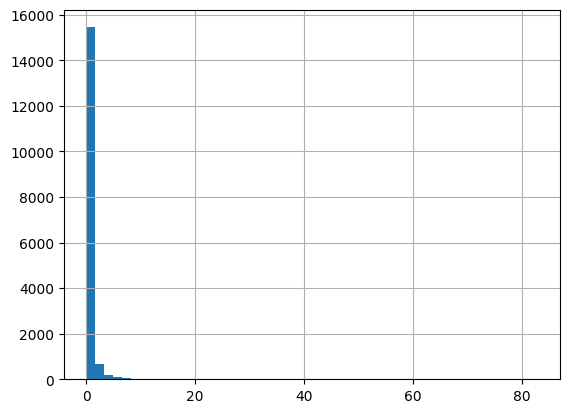

In [241]:
df["Global Sales"].hist(bins=50)
plt.show()

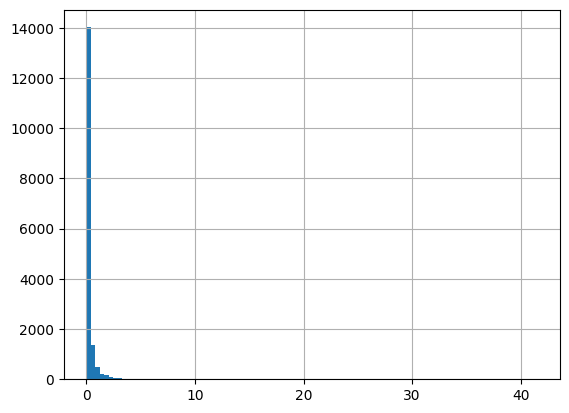

In [242]:
df["NA Sales"].hist(bins=100)
plt.show()

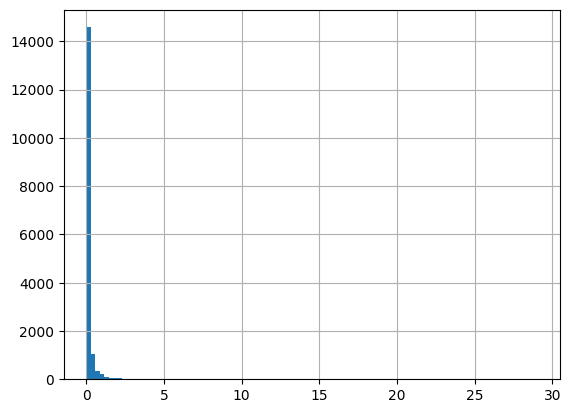

In [243]:
df["EU Sales"].hist(bins=100)
plt.show()

In [244]:
counts = df['Platform Group'].value_counts()
counts

Platform Group
PS          6632
Nintendo    6248
XBox        2293
PC          1111
Sega         259
Name: count, dtype: int64

In [245]:
df['Genre'].value_counts()

Genre
Action          3308
Sports          2337
Misc            1727
Role-Playing    1486
Shooter         1308
Adventure       1281
Racing          1243
Platform         884
Simulation       864
Fighting         846
Strategy         679
Puzzle           580
Name: count, dtype: int64

In [246]:
ohe=OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
dfEncode = ohe.fit_transform(df[['Platform Group','Genre']])
df=pd.concat([df,dfEncode],axis=1).drop(columns=['Platform Group','Genre'])
df.drop('Name',axis=1,inplace=True)
df.drop('Platform',axis=1,inplace=True)
df.drop('Publisher',axis=1,inplace=True)
df.head(2)

,Rank,Year,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Platform Group_Nintendo,Platform Group_PC,Platform Group_PS,...,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy
0,1,2006,41.49,29.02,3.77,8.46,82.74,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,1985,29.08,3.58,6.81,0.77,40.24,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: >

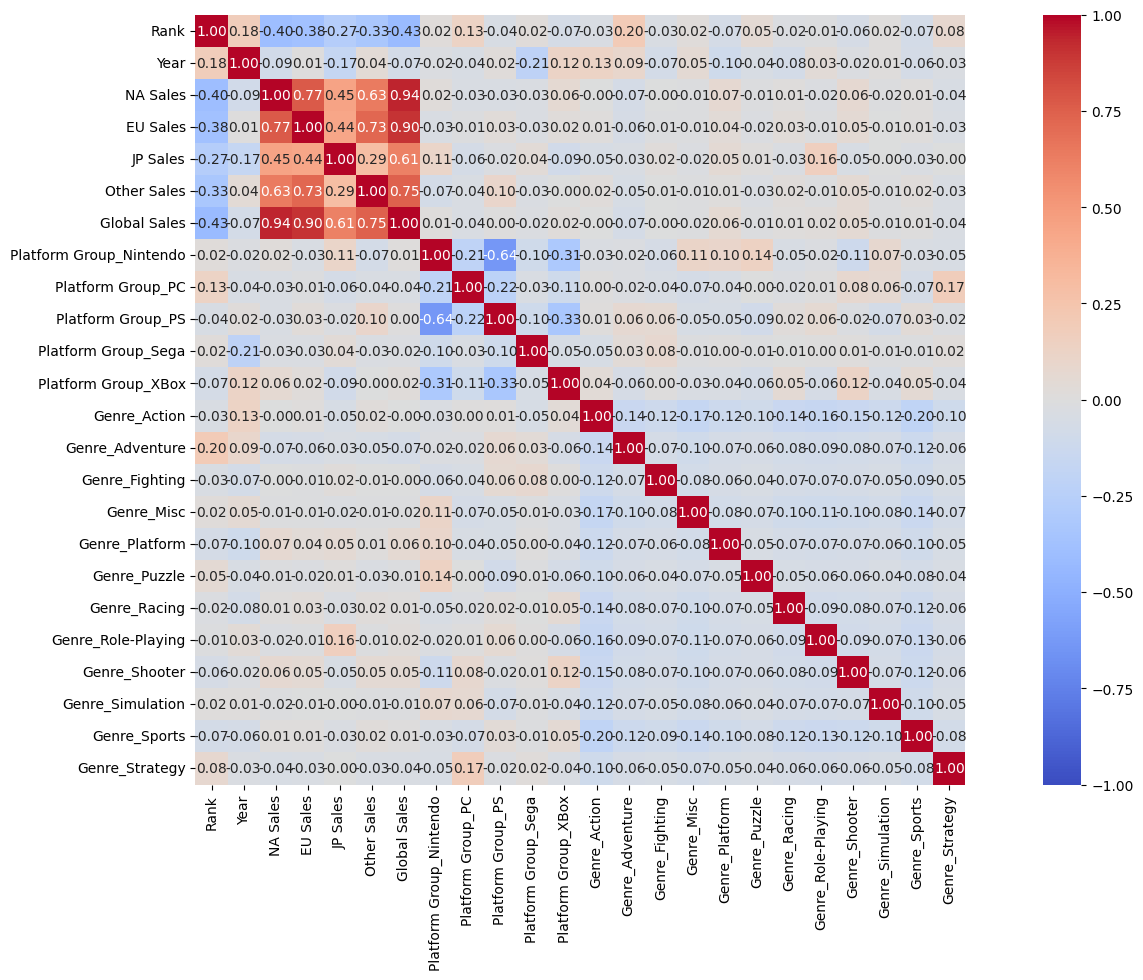

In [247]:
corr = df.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, 
            annot=True,     # Show numerical values
            cmap='coolwarm',# Good color scale for correlation (-1 to 1)
            fmt=".2f",      # Format values to 2 decimal places
            vmin=-1, vmax=1,# Define range for heatmap
            square=True)    # Make cells square

In [248]:
df.columns

Index(['Rank', 'Year', 'NA Sales', 'EU Sales', 'JP Sales', 'Other Sales',
       'Global Sales', 'Platform Group_Nintendo', 'Platform Group_PC',
       'Platform Group_PS', 'Platform Group_Sega', 'Platform Group_XBox',
       'Genre_Action', 'Genre_Adventure', 'Genre_Fighting', 'Genre_Misc',
       'Genre_Platform', 'Genre_Puzzle', 'Genre_Racing', 'Genre_Role-Playing',
       'Genre_Shooter', 'Genre_Simulation', 'Genre_Sports', 'Genre_Strategy'],
      dtype='str')

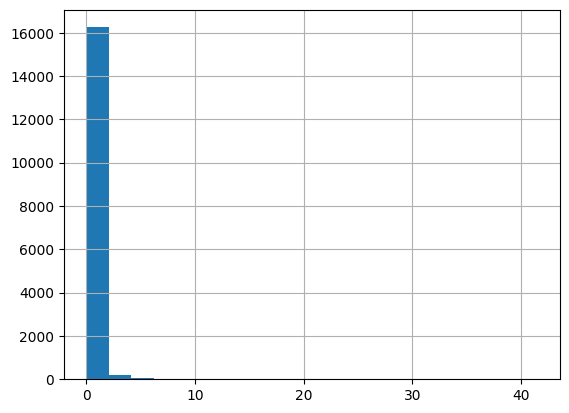

In [249]:
df["NA Sales"].hist(bins=20)
plt.show()

In [ ]:
def logTransform(df,featureColumns,targetColumn):
    for col in featureColumns:
        df[col] = np.log1p(df[col])
    df[targetColumn] = np.log1p(df[targetColumn])

def standardScale(df,featureColumns,targetColumn):
    featureScaler=StandardScaler()
    for col in featureColumns:
        df[[col]] = featureScaler.fit_transform(df[[col]])
    targetScaler=StandardScaler()
    df[[targetColumn]] = targetScaler.fit_transform(df[[targetColumn]])


def featureEngineer(df,featureColumns,targetColumn):
    logTransform(df,featureColumns,targetColumn)
    standardScale(df,featureColumns,targetColumn)
    return df


featureColumns = ['NA Sales']
df=featureEngineer(df,featureColumns,'Global Sales')





<Axes: >

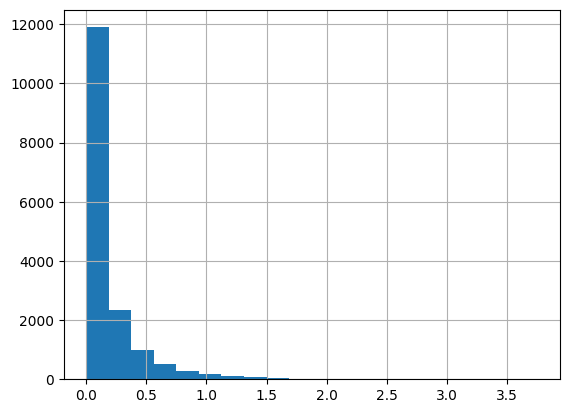

In [251]:
df["NA Sales"].hist(bins=20)